<a href="https://colab.research.google.com/github/shafirahsnr/footwear-sales-analysis/blob/main/Footwear_Sales_%26_Customer_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Footwear Sales Analysis

## Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv('Footwear.csv')
df.head(10)

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0
5,ORD100005,2021-08-27,Nike,Model-158,Gym,Unisex,7,Grey,148,0,148.00,3,444.0,Wallet,Retail Store,UK,Low,3.1
6,ORD100006,2019-02-21,Reebok,Model-786,Gym,Women,11,Black,74,30,51.80,2,103.6,Bank Transfer,Online,UAE,High,3.4
7,ORD100007,2020-05-17,New Balance,Model-604,Lifestyle,Women,8,White,114,15,96.90,4,387.6,Bank Transfer,Online,USA,High,4.7
8,ORD100008,2022-03-30,New Balance,Model-266,Running,Unisex,7,Grey,194,20,155.20,1,155.2,Bank Transfer,Retail Store,UK,High,4.9
9,ORD100009,2026-03-11,Nike,Model-876,Gym,Unisex,7,Black,119,30,83.30,2,166.6,Card,Retail Store,USA,Medium,3.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  object 
 1   order_date             30000 non-null  object 
 2   brand                  30000 non-null  object 
 3   model_name             30000 non-null  object 
 4   category               30000 non-null  object 
 5   gender                 30000 non-null  object 
 6   size                   30000 non-null  int64  
 7   color                  30000 non-null  object 
 8   base_price_usd         30000 non-null  int64  
 9   discount_percent       30000 non-null  int64  
 10  final_price_usd        30000 non-null  float64
 11  units_sold             30000 non-null  int64  
 12  revenue_usd            30000 non-null  float64
 13  payment_method         30000 non-null  object 
 14  sales_channel          30000 non-null  object 
 15  co

In [ ]:
df.describe()

,size,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,customer_rating
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,8.500867,139.634633,13.332167,121.029035,2.500200,302.714948,4.001543
std,1.710896,46.062549,9.864198,42.511586,1.121149,179.149272,0.577546
min,6.000000,60.000000,0.000000,42.000000,1.000000,42.000000,3.000000
25%,7.000000,100.000000,5.000000,85.000000,1.000000,156.750000,3.500000
50%,9.000000,140.000000,10.000000,119.200000,3.000000,268.200000,4.000000
75%,10.000000,180.000000,20.000000,153.600000,4.000000,414.000000,4.500000
max,11.000000,219.000000,30.000000,219.000000,4.000000,876.000000,5.000000


#### Dataset Footwear.csv merupakan data penjualan, harga, dan konsumen untuk sepatu olahraga dari tahun 2018 hingga 2026. Dataset ini mencakup berbagai merek global (Nike, Adidas, Puma, Reebok, ASICS, New Balance). Dataset ini terdiri atas 18 kolom dan 30000 baris. Berdasarkan dataset ini dilakukan analisis penjualan, harga, dan behavior pelanggan sehingga hasil analisis dapat digunakan untuk mendukung pengambilan keputusan bisnis.

## Data Cleaning

### Duplicate Handling

In [ ]:
len(df.drop_duplicates()) / len(df)

1.0

#### Tidak terdapat duplikasi pada dataset

### Outlier Handling

In [ ]:
import scipy.stats as stats

In [ ]:
def check_plot(df, variable):

    # ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

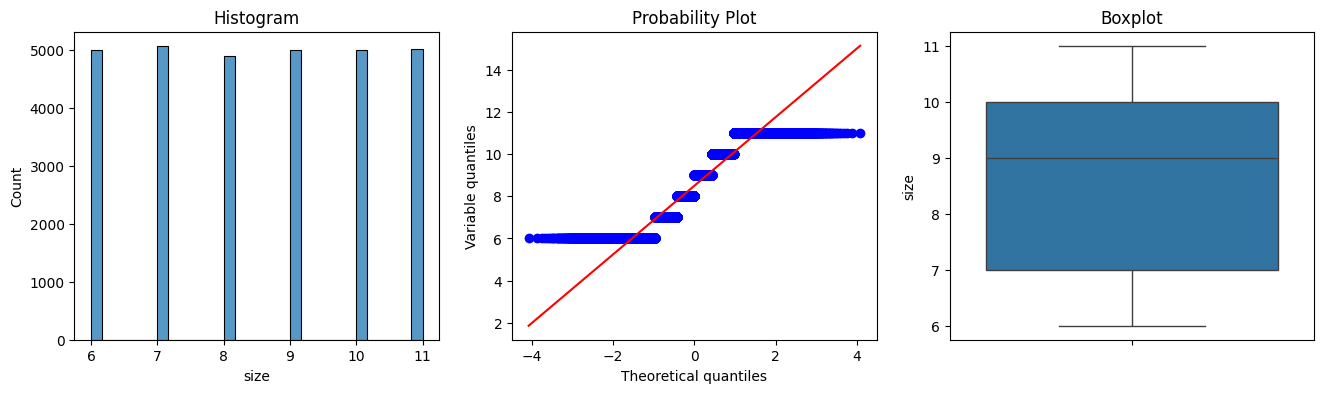

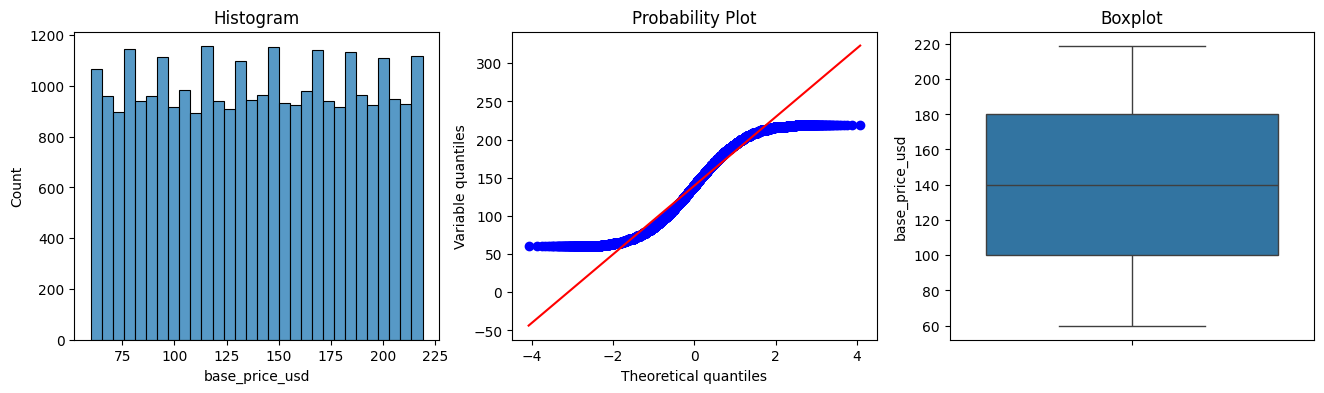

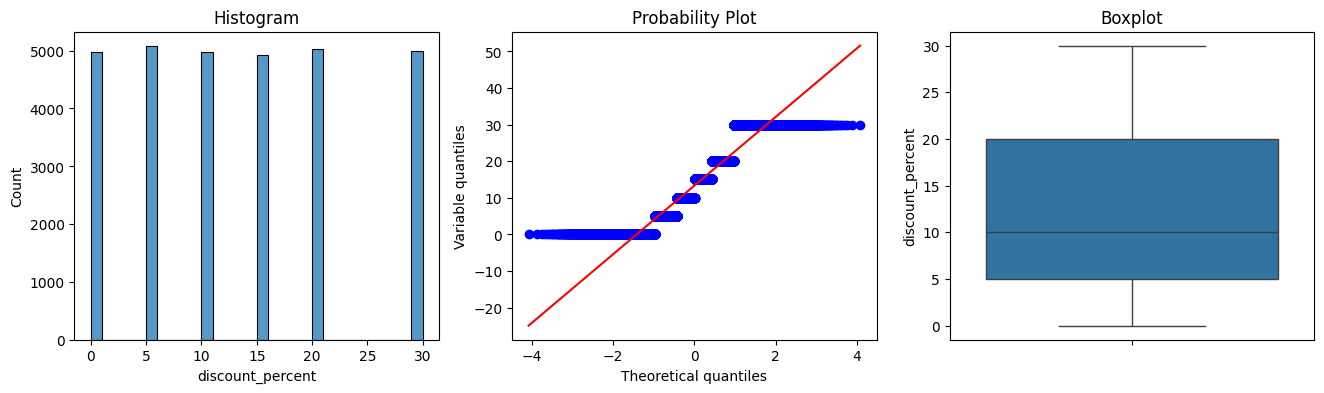

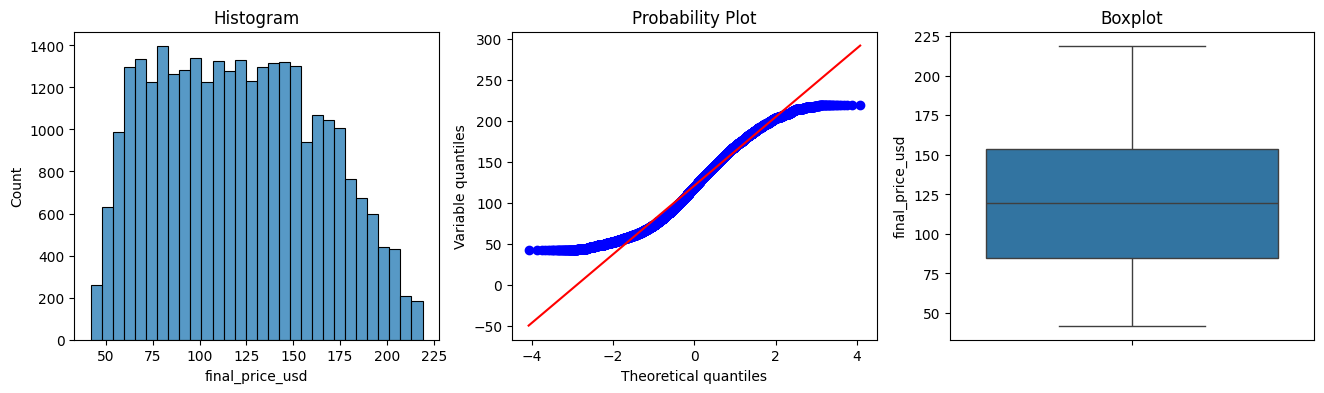

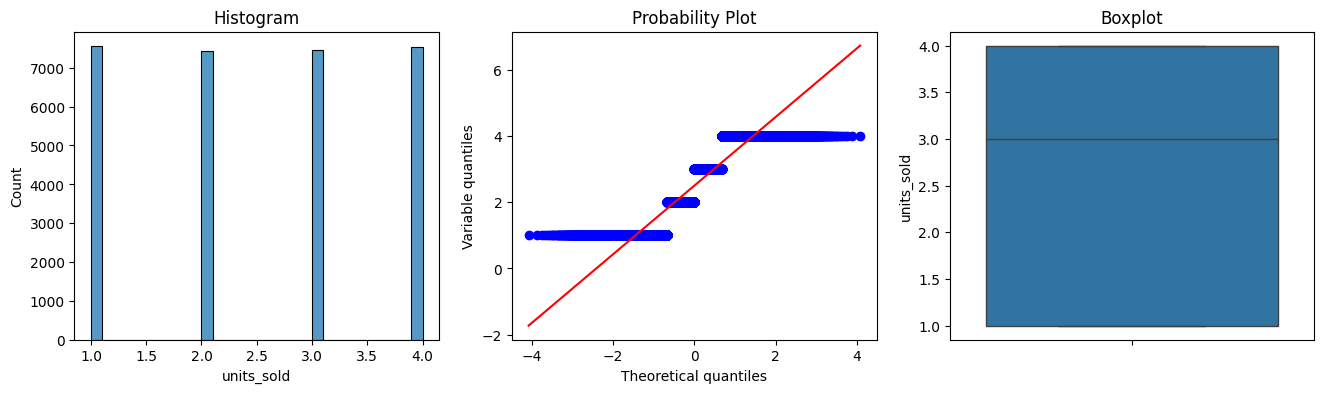

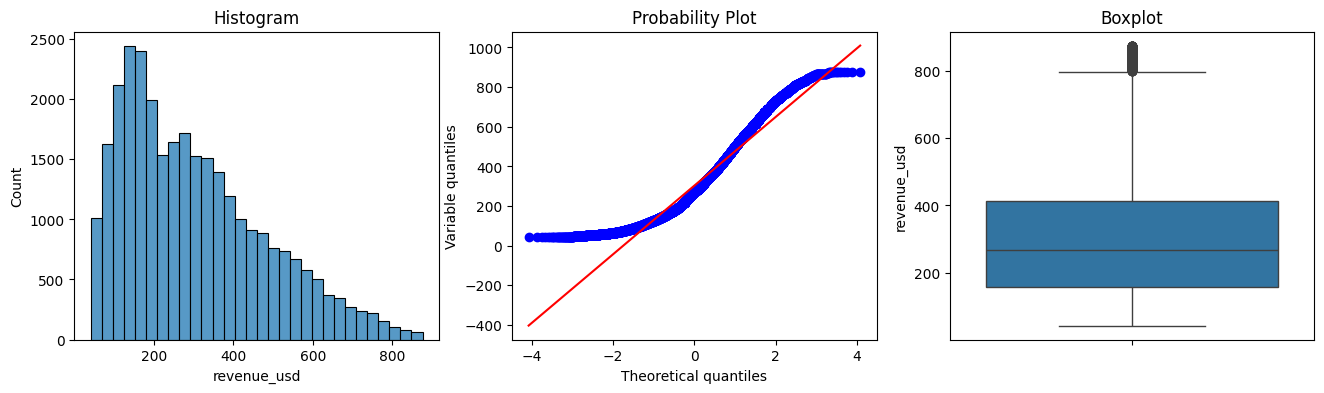

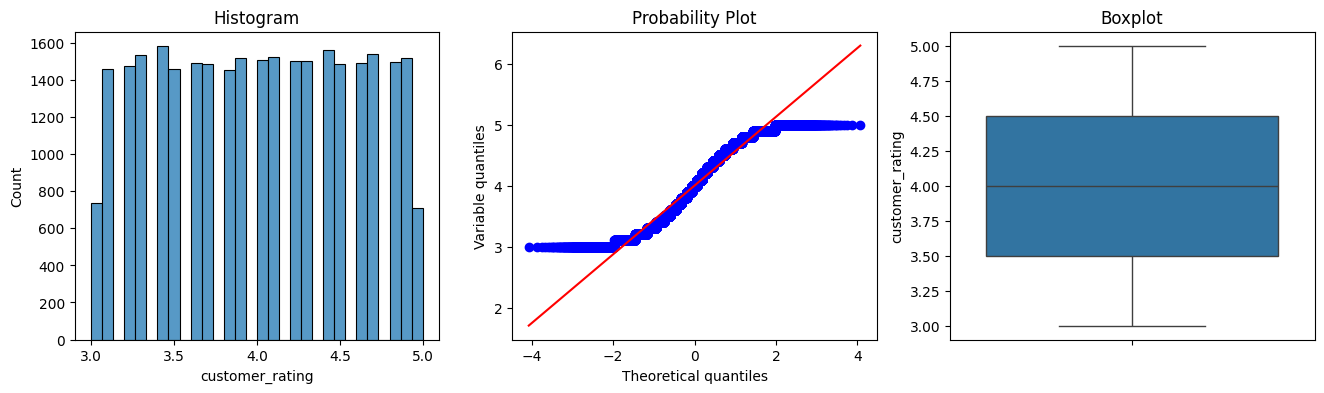

In [ ]:
kolom_num = ['size','base_price_usd','discount_percent','final_price_usd','units_sold','revenue_usd','customer_rating']

for nama_kolom in kolom_num:
    check_plot(df, nama_kolom)

#### Berdasarkan hasil visualisasi menggunakan histogram, probability plot, dan boxplot yang dilakukan pada kolom kolom numerik. Hasil pengamatan menunjukkan bahwa sebagian besar variabel tidak memiliki outlier. Pada variabel revenue_usd terdapat beberapa nilai yang relatif tinggi, namun nilai tersebut masih berada dalam rentang yang masuk akal secara bisnis sehingga tetap dipertahankan dan tidak dianggap sebagai outlier.



### Missing Value Handling

In [ ]:
df.isna().sum()

,0
order_id,0
order_date,0
brand,0
model_name,0
category,0
gender,0
size,0
color,0
base_price_usd,0
discount_percent,0


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
brand,0
model_name,0
category,0
gender,0
size,0
color,0
base_price_usd,0
discount_percent,0


In [ ]:
for column in df.columns:
    print(f"============= {column} =================")
    display(df[column].value_counts())
    print()

============= order_id =================


,count
order_id,
ORD129983,1
ORD129982,1
ORD129981,1
ORD129980,1
ORD129979,1
ORD129978,1
ORD129977,1
ORD129976,1
ORD129975,1



============= order_date =================


,count
order_date,
2022-09-20,21
2023-05-22,21
2019-08-29,21
2020-04-12,21
2022-03-07,21
2018-02-05,20
2020-06-01,20
2025-07-25,20
2019-11-30,20



============= brand =================


...

,count
country,
UAE,5118
UK,5058
USA,5027
India,4991
Germany,4965
Pakistan,4841



============= customer_income_level =================


,count
customer_income_level,
High,10059
Medium,9997
Low,9944



============= customer_rating =================


,count
customer_rating,
3.4,1580
4.4,1559
4.7,1536
3.3,1534
4.1,1521
4.9,1517
3.9,1516
4.0,1504
4.3,1503


#### Tidak terdapat missing value atau nilai yang tidak sesuai

## Data Transform

In [ ]:
# Mengubah tipe data kolom order_date ke datetime
df["order_date"] = pd.to_datetime(df["order_date"],format="%Y-%m-%d")

In [ ]:
# Membuat kolom tanggal, bulan, tahun
df["day"] = df["order_date"].dt.day
df["month"] = df["order_date"].dt.month
df["year"] = df["order_date"].dt.year

In [ ]:
# Mengubah tipe data kolom customer_income_level ke categorical
order = ['Low','Medium','High']
df['customer_income_level'] = pd.Categorical(df['customer_income_level'],
                                             categories=order,ordered=True)

In [ ]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,day,month,year
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6,30,1,2021
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9,5,10,2026
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0,12,11,2023
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4,29,8,2026
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0,9,11,2019


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               30000 non-null  object        
 1   order_date             30000 non-null  datetime64[ns]
 2   brand                  30000 non-null  object        
 3   model_name             30000 non-null  object        
 4   category               30000 non-null  object        
 5   gender                 30000 non-null  object        
 6   size                   30000 non-null  int64         
 7   color                  30000 non-null  object        
 8   base_price_usd         30000 non-null  int64         
 9   discount_percent       30000 non-null  int64         
 10  final_price_usd        30000 non-null  float64       
 11  units_sold             30000 non-null  int64         
 12  revenue_usd            30000 non-null  float64       
 13  p

## EDA

In [ ]:
# Mengambil data tahun 2025
df_25 = df[df['year']==2025]
df_25.head(10)

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,day,month,year
12,ORD100012,2025-09-20,Puma,Model-871,Lifestyle,Men,11,White,193,30,135.10,2,270.20,Wallet,Retail Store,UAE,Low,3.1,20,9,2025
37,ORD100037,2025-05-27,Adidas,Model-346,Basketball,Unisex,9,Grey,219,30,153.30,4,613.20,Cash,Retail Store,Germany,Low,3.2,27,5,2025
38,ORD100038,2025-02-20,Adidas,Model-393,Lifestyle,Men,10,Grey,182,0,182.00,3,546.00,Card,Online,UK,High,4.3,20,2,2025
44,ORD100044,2025-10-17,Nike,Model-863,Training,Women,7,Black,101,10,90.90,3,272.70,Card,Online,UK,Medium,5.0,17,10,2025
46,ORD100046,2025-12-27,Nike,Model-108,Lifestyle,Women,6,White,96,10,86.40,3,259.20,Cash,Online,UAE,Medium,3.7,27,12,2025
62,ORD100062,2025-05-08,New Balance,Model-953,Training,Unisex,7,Blue,83,5,78.85,4,315.40,Cash,Retail Store,USA,Medium,3.5,8,5,2025
63,ORD100063,2025-05-20,Adidas,Model-203,Basketball,Unisex,6,Blue,189,5,179.55,1,179.55,Cash,Online,India,Medium,3.3,20,5,2025
74,ORD100074,2025-11-13,Reebok,Model-216,Running,Unisex,11,Blue,149,20,119.20,2,238.40,Cash,Retail Store,UK,High,4.7,13,11,2025
79,ORD100079,2025-07-07,Adidas,Model-168,Gym,Women,6,White,88,30,61.60,4,246.40,Cash,Online,USA,High,3.6,7,7,2025
99,ORD100099,2025-03-23,Reebok,Model-990,Running,Women,10,Grey,199,0,199.00,4,796.00,Card,Online,UK,Low,4.5,23,3,2025


### Product Performance

In [ ]:
# Unit sold by brand
df_brand_unit = df_25.groupby('brand')['units_sold'].sum().reset_index().sort_values(by='units_sold',ascending=False)
df_brand_unit

,brand,units_sold
2,New Balance,1510
1,Adidas,1429
5,Reebok,1423
3,Nike,1410
0,ASICS,1366
4,Puma,1345


#### Brand dengan penjualan terbanyak tahun 2025 adalah New Balance

In [ ]:
# Revenue by brand
df_brand_rev = df_25.groupby('brand')['revenue_usd'].sum().reset_index().sort_values(by='revenue_usd',ascending=False)
df_brand_rev

,brand,revenue_usd
2,New Balance,182247.80
1,Adidas,172882.10
3,Nike,170818.15
5,Reebok,168902.60
0,ASICS,165008.25
4,Puma,164237.95


#### Brand dengan revenue tertinggi tahun 2025 adalah New Balance

In [ ]:
# Category dengan revenue tertinggi untuk masing masing brand
top_brand_category = (
    df_25.groupby(['brand', 'category'])['revenue_usd']
    .sum()
    .reset_index()
)

top_brand_category = top_brand_category.loc[
    top_brand_category.groupby('brand')['revenue_usd'].idxmax()
].sort_values(by='revenue_usd', ascending=False)

top_brand_category

,brand,category,revenue_usd
15,Nike,Basketball,42346.80
20,Puma,Basketball,40092.15
7,Adidas,Lifestyle,38737.40
12,New Balance,Lifestyle,37844.10
25,Reebok,Basketball,36547.65
0,ASICS,Basketball,36348.35


#### Category dengan revenue tertinggi untuk masing masing brand
1.   Nike : Basketball
2.   Puma : Basketball
3. Adidas : Lifestyle
4. New Balance : Lifestyle
5. Reebok : Basketball
6. ASICS : Basketball



In [ ]:
# Model dengan revenue tertinggi untuk masing masing brand
top_brand_model = (
    df_25.groupby(['brand', 'model_name'])['revenue_usd']
    .sum()
    .reset_index()
)

top_brand_model = top_brand_model.loc[
    top_brand_model.groupby('brand')['revenue_usd'].idxmax()
].sort_values(by='revenue_usd', ascending=False)

top_brand_model

,brand,model_name,revenue_usd
1174,New Balance,Model-820,1919.2
1570,Nike,Model-760,1892.8
2105,Reebok,Model-152,1797.8
586,Adidas,Model-491,1776.9
74,ASICS,Model-242,1664.5
1829,Puma,Model-427,1432.0


#### Model dengan revenue tertinggi untuk masing masing brand
1. New Balance : Model-820
2. Nike : Model-760
3. Reebok : Model-152
4. Adidas : Model-491
5. ASICS : Model-242
6. Puma : Model-427

In [ ]:
# Unit sold by gender
df_gender_unit = df_25.groupby('gender')['units_sold'].sum().reset_index().sort_values(by='units_sold',ascending=False)
df_gender_unit

,gender,units_sold
1,Unisex,2936
0,Men,2844
2,Women,2703


#### Tipe gender sepatu yang terjual paling banyak adalah unisex

In [ ]:
# Customer rating by brand
df_brand_rate = df_25.groupby(['brand'])[['customer_rating']].mean().reset_index().sort_values(by='customer_rating',ascending=False)
df_brand_rate

,brand,customer_rating
0,ASICS,4.015543
3,Nike,4.013251
4,Puma,3.978860
2,New Balance,3.970377
5,Reebok,3.969176
1,Adidas,3.960708


#### Brand yang memiliki rata rata rating tertinggi adalah ASICS

### Pricing & Demand

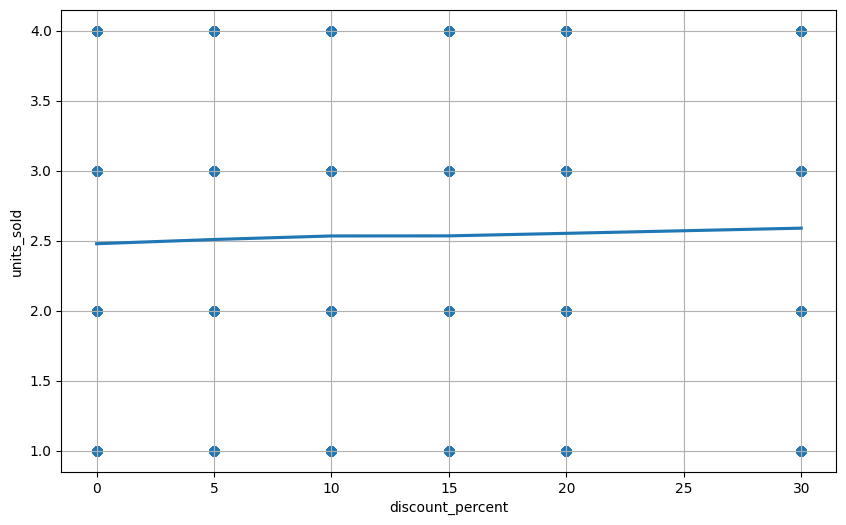

In [ ]:
# Discount vs Unit sold
plt.figure(figsize=(10, 6))
scatter_plot = sns.regplot(data=df_25, x='discount_percent', y='units_sold', lowess=True)
plt.grid()

plt.show()

#### Semakin besar discount, jumlah unit yang dibeli dalam sekali pembelian cenderung meningkat

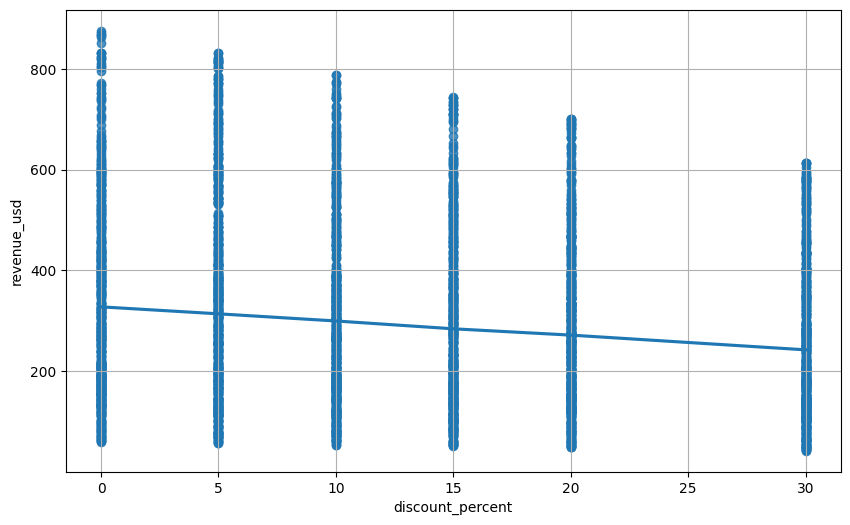

In [ ]:
# Discount vs Revenue
plt.figure(figsize=(10, 6))
scatter_plot = sns.regplot(data=df_25, x='discount_percent', y='revenue_usd', lowess=True)
plt.grid()

plt.show()

#### Semakin besar discount, jumlah revenue yang diperoleh dalam sekali pembelian cenderung menurun

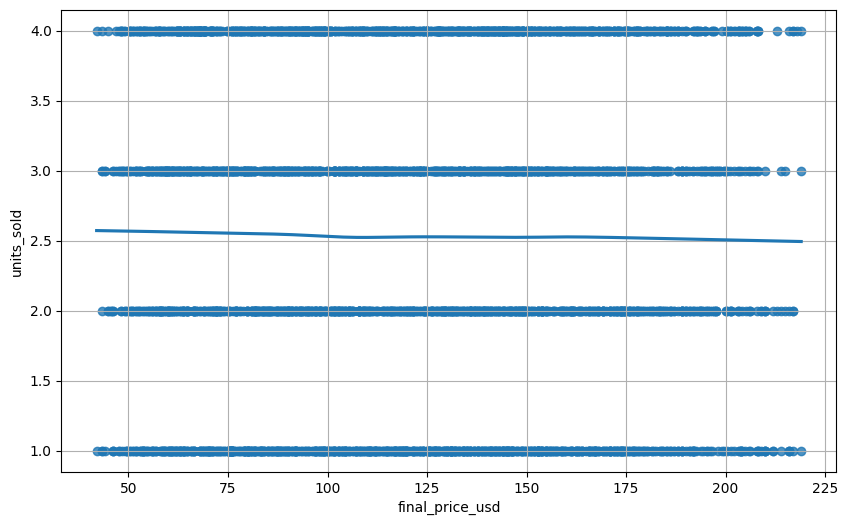

In [ ]:
# Final price vs Unit sold
plt.figure(figsize=(10, 6))
scatter_plot = sns.regplot(data=df_25, x='final_price_usd', y='units_sold', lowess=True)
plt.grid()

plt.show()

#### Semakin besar final price (harga setelah diskon), jumlah unit yang dibeli dalam sekali pembelian cenderung menurun

### Market & Channel

In [ ]:
# Unit sold by sales channel
df_channel_unit = df_25.groupby('sales_channel')['units_sold'].sum().reset_index().sort_values(by='units_sold',ascending=False)
df_channel_unit

,sales_channel,units_sold
0,Online,4274
1,Retail Store,4209


#### Sales channel dengan penjualan tertinggi adalah online

In [ ]:
# Revenue by sales channel
df_channel_rev= df_25.groupby('sales_channel')['revenue_usd'].sum().reset_index().sort_values(by='revenue_usd',ascending=False)
df_channel_rev

,sales_channel,revenue_usd
0,Online,512724.50
1,Retail Store,511372.35


#### Sales channel dengan revenue tertinggi adalah online

In [ ]:
# Revenue by country
df_country_rev = df_25.groupby('country')['revenue_usd'].sum().reset_index().sort_values(by='revenue_usd',ascending=False)
df_country_rev

,country,revenue_usd
4,UK,179080.30
3,UAE,177960.05
5,USA,170314.60
0,Germany,168397.20
2,Pakistan,165377.90
1,India,162966.80


#### Negara dengan revenue tertinggi adalah UK

In [ ]:
# Brand dengan unit sold tertinggi untuk masing masing country
top_brand_country = (
    df_25.groupby(['country', 'brand'])['units_sold']
    .sum()
    .reset_index()
)

top_brand_country = top_brand_country.loc[
    top_brand_country.groupby('country')['units_sold'].idxmax()
].sort_values(by='units_sold', ascending=False)

top_brand_country

,country,brand,units_sold
19,UAE,Adidas,296
32,USA,New Balance,280
29,UK,Reebok,279
15,Pakistan,Nike,271
8,India,New Balance,255
5,Germany,Reebok,254


#### Brand dengan unit sold tertinggi untuk masing masing country
1. UAE : Adidas
2. USA : New Balance
3. UK : Reebok
4. Pakistan : Nike
5. India : New Balance
6. Germany : Reebok

### Consumer Analysis

In [ ]:
# Customer income level vs revenue
df_income_rev = df_25.groupby('customer_income_level')['revenue_usd'].agg(['min','max','mean']).reset_index().sort_values(by='customer_income_level')
df_income_rev

/tmp/ipykernel_872/1866137820.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_income_rev = df_25.groupby('customer_income_level')['revenue_usd'].agg(['min','max','mean']).reset_index().sort_values(by='customer_income_level')


,customer_income_level,min,max,mean
0,Low,43.4,872.0,311.770130
1,Medium,42.0,876.0,297.651131
2,High,43.4,868.0,307.835854


/tmp/ipykernel_872/1616408801.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_25['income_encoded'] = df_25['customer_income_level'].map(mapping)


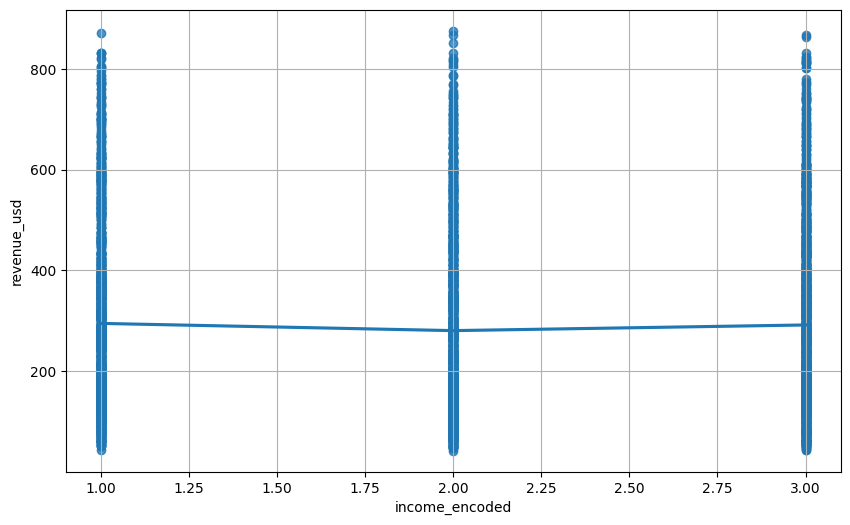

In [ ]:
mapping = {'Low':1, 'Medium':2, 'High':3}
df_25['income_encoded'] = df_25['customer_income_level'].map(mapping)

plt.figure(figsize=(10, 6))
scatter_plot = sns.regplot(data=df_25, x='income_encoded', y='revenue_usd', lowess=True)
plt.grid()

plt.show()

#### Jumlah revenue yang dihasilkan oleh income level low, medium, dan high cenderung tidak jauh berbeda untuk sekali transaksi